# EDA - MrScraper Price Intelligence

This notebook explores the train/test data before modeling. The goal is to understand:

- train/test timing and overlap
- missingness patterns
- price distribution and outliers
- entity coverage between train and test
- product/shop/category historical stability
- anchor availability in the test file
- where validation errors are likely to come from

The modeling pipeline lives in `src/` and the main report is in `notebook.ipynb`.


In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(str(Path.cwd()))

from src.config import PipelineConfig
from src.data import load_data, basic_preprocess

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

config = PipelineConfig()
train_raw, test_raw = load_data(config.train_path, config.test_path)
train = basic_preprocess(train_raw, config)
test = basic_preprocess(test_raw, config)

print("Train:", train.shape)
print("Test:", test.shape)


Train: (306226, 27)
Test: (25900, 27)


## 1. Dataset Overview

Basic shape, date range, and missing target count. This confirms the outage setup and whether train/test are split by date or timestamp.


In [2]:
def dataset_overview(df, name):
    return {
        "dataset": name,
        "rows": len(df),
        "columns": df.shape[1],
        "min_capturedAt": df[config.date_col].min(),
        "max_capturedAt": df[config.date_col].max(),
        "missing_price": df[config.target].isna().sum(),
        "known_price": df[config.target].notna().sum(),
        "unique_shopId": df["shopId"].nunique(),
        "unique_itemId": df["itemId"].nunique(),
        "unique_modelId": df["modelId"].nunique(),
    }

pd.DataFrame([
    dataset_overview(train, "train"),
    dataset_overview(test, "test"),
])


,dataset,rows,columns,min_capturedAt,max_capturedAt,missing_price,known_price,unique_shopId,unique_itemId,unique_modelId
0,train,306226,27,2025-01-01 22:37:36.424,2025-03-22 04:27:05.302,0,306226,219,1594,6286
1,test,25900,27,2025-03-22 04:27:05.325,2025-03-24 23:30:04.453,25600,300,150,953,3871


In [3]:
print("Train max timestamp:", train[config.date_col].max())
print("Test min timestamp: ", test[config.date_col].min())
print("Gap:", test[config.date_col].min() - train[config.date_col].max())


Train max timestamp: 2025-03-22 04:27:05.302000
Test min timestamp:  2025-03-22 04:27:05.325000
Gap: 0 days 00:00:00.023000


## 2. Schema And Missingness

Missingness matters because the test file has many blank feature columns. This table shows which fields are useful at prediction time and which are mostly unavailable.


In [4]:
def missingness_table(train_df, test_df):
    rows = []
    for col in train_df.columns:
        rows.append({
            "column": col,
            "train_dtype": str(train_df[col].dtype),
            "test_dtype": str(test_df[col].dtype) if col in test_df.columns else "missing_column",
            "train_missing_pct": train_df[col].isna().mean() * 100,
            "test_missing_pct": test_df[col].isna().mean() * 100 if col in test_df.columns else np.nan,
            "train_nunique": train_df[col].nunique(dropna=True),
            "test_nunique": test_df[col].nunique(dropna=True) if col in test_df.columns else np.nan,
        })
    return pd.DataFrame(rows).sort_values("test_missing_pct", ascending=False)

missingness = missingness_table(train_raw, test_raw)
missingness


,column,train_dtype,test_dtype,train_missing_pct,test_missing_pct,train_nunique,test_nunique
9,normal_stock,float64,float64,98.7793,99.9730,1,1
8,stock,float64,float64,98.7793,99.9730,1,1
12,brand,str,str,34.5052,99.3591,376,72
7,cat_id,int64,float64,0.0000,98.8417,26,22
5,priceBeforeDiscount,int64,float64,0.0000,98.8417,325,62
6,promotionId,int64,float64,0.0000,98.8417,213,21
13,is_free_shipping,str,str,0.0000,98.8417,2,2
11,show_discount,int64,float64,0.0000,98.8417,84,45
10,raw_discount,int64,float64,0.0000,98.8417,84,45
4,price,int64,float64,0.0000,98.8417,852,140


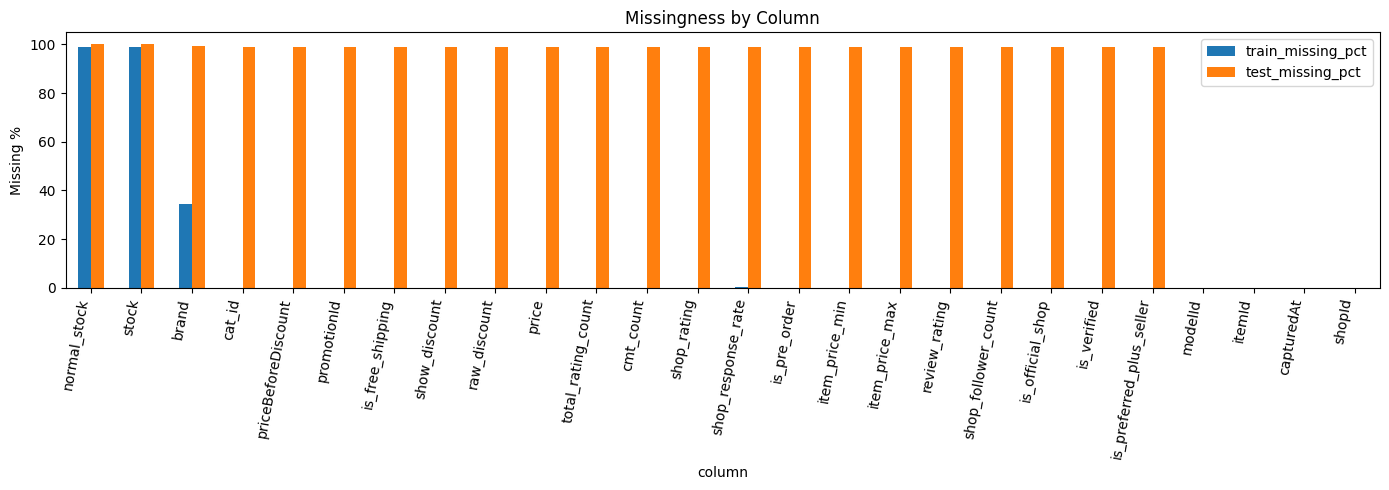

In [5]:
missingness.plot(
    x="column",
    y=["train_missing_pct", "test_missing_pct"],
    kind="bar",
    figsize=(14, 5),
    title="Missingness by Column",
)
plt.xticks(rotation=80, ha="right")
plt.ylabel("Missing %")
plt.tight_layout()
plt.show()


## 3. Rows Over Time

Counts by day show scrape density, validation-day size, and the outage window.


In [6]:
train_daily = train.groupby("date").size().rename("train_rows")
test_daily = test.groupby("date").size().rename("test_rows")
daily_counts = pd.concat([train_daily, test_daily], axis=1).fillna(0).astype(int)
daily_counts.tail(20)


,train_rows,test_rows
date,,
2025-03-05,8171,0
2025-03-06,7289,0
2025-03-07,8334,0
2025-03-08,8414,0
2025-03-09,8522,0
2025-03-10,6692,0
2025-03-11,8360,0
2025-03-12,8896,0
2025-03-13,8284,0


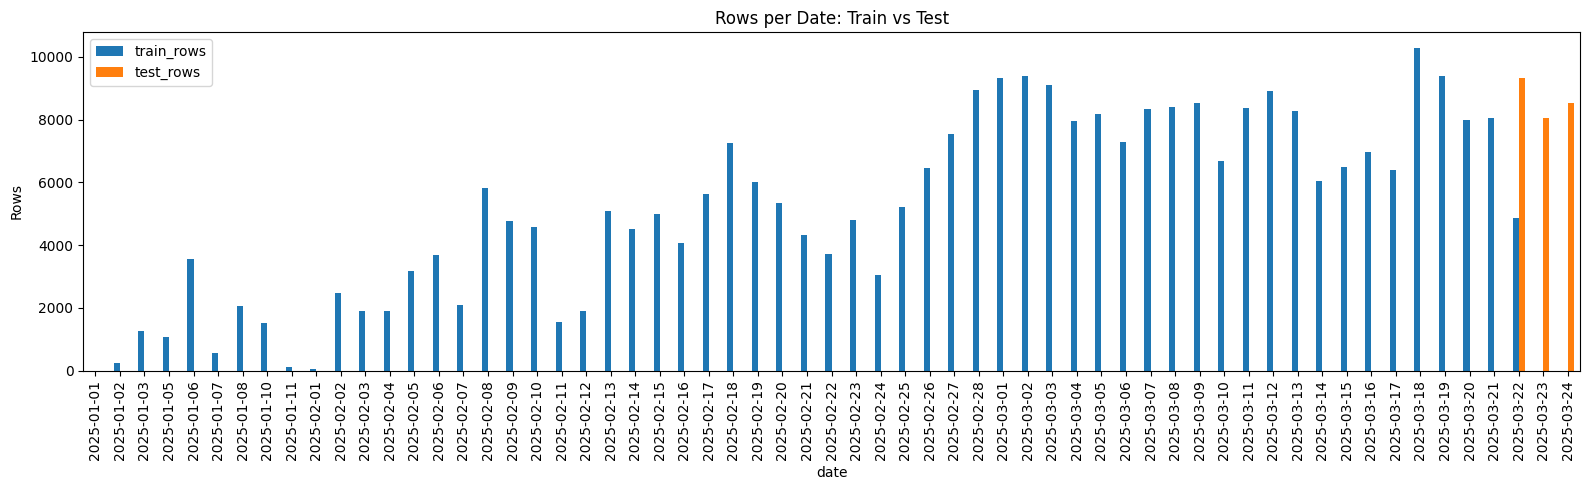

In [7]:
daily_counts.plot(kind="bar", figsize=(16, 5), title="Rows per Date: Train vs Test")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()


## 4. Price Distribution

Prices are heavily skewed, so the pipeline models `log1p(price)`. These plots show why raw-price errors and percentage errors can behave differently.


In [8]:
price = train[config.target].dropna().astype(float)
price_summary = price.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
price_summary.to_frame("price")


,price
count,"306,226.0000"
mean,"52,341,462.1881"
std,"91,371,957.2705"
min,"100,000.0000"
1%,"1,200,000.0000"
5%,"3,500,000.0000"
25%,"9,900,000.0000"
50%,"20,500,000.0000"
75%,"59,000,000.0000"
95%,"180,000,000.0000"


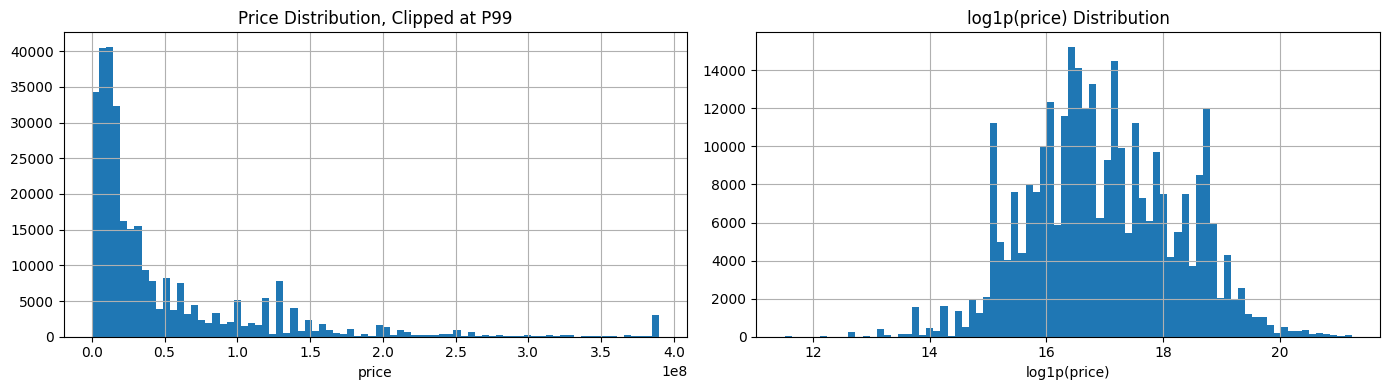

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

price.clip(upper=price.quantile(0.99)).hist(bins=80, ax=axes[0])
axes[0].set_title("Price Distribution, Clipped at P99")
axes[0].set_xlabel("price")

np.log1p(price).hist(bins=80, ax=axes[1])
axes[1].set_title("log1p(price) Distribution")
axes[1].set_xlabel("log1p(price)")

plt.tight_layout()
plt.show()


In [10]:
train.assign(price_bucket=pd.qcut(train[config.target], q=10, duplicates="drop"))     .groupby("price_bucket", observed=True)     .agg(
        rows=(config.target, "size"),
        min_price=(config.target, "min"),
        median_price=(config.target, "median"),
        max_price=(config.target, "max"),
        unique_modelId=("modelId", "nunique"),
    )


,rows,min_price,median_price,max_price,unique_modelId
price_bucket,,,,,
"(99999.999, 4500000.0]",31694,100000,"3,600,000.0000",4500000,603
"(4500000.0, 8000000.0]",29690,4600000,"6,900,000.0000",8000000,657
"(8000000.0, 11800000.0]",31913,8100000,"9,900,000.0000",11800000,650
"(11800000.0, 15500000.0]",29648,11900000,"13,500,000.0000",15500000,607
"(15500000.0, 20500000.0]",30237,15600000,"17,900,000.0000",20500000,682
"(20500000.0, 29900000.0]",30602,20600000,"25,900,000.0000",29900000,642
"(29900000.0, 48000000.0]",31376,30000000,"38,000,000.0000",48000000,683
"(48000000.0, 78400000.0]",29835,48400000,"59,600,000.0000",78400000,764
"(78400000.0, 130000000.0]",32739,78500000,"109,600,000.0000",130000000,771


## 5. Entity Coverage Between Train And Test

This checks cold-start risk. If most test IDs exist in train, historical features should be strong. If many are unseen, fallback logic matters more.


In [11]:
def coverage(train_df, test_df, col):
    train_set = set(train_df[col].dropna().astype(str))
    test_values = test_df[col].dropna().astype(str)
    seen_mask = test_values.isin(train_set)
    return {
        "entity": col,
        "test_unique": test_values.nunique(),
        "test_rows": len(test_values),
        "rows_seen_in_train": seen_mask.sum(),
        "rows_unseen_in_train": (~seen_mask).sum(),
        "row_seen_pct": seen_mask.mean() * 100 if len(test_values) else np.nan,
        "unique_seen_pct": len(set(test_values) & train_set) / max(test_values.nunique(), 1) * 100,
    }

coverage_df = pd.DataFrame([coverage(train, test, col) for col in ["shopId", "itemId", "modelId", "cat_id", "brand"]])
coverage_df


,entity,test_unique,test_rows,rows_seen_in_train,rows_unseen_in_train,row_seen_pct,unique_seen_pct
0,shopId,150,25900,25900,0,100.0000,100.0000
1,itemId,953,25900,25900,0,100.0000,100.0000
2,modelId,3871,25900,25898,2,99.9923,99.9483
3,cat_id,23,25900,0,25900,0.0000,0.0000
4,brand,73,25900,25900,0,100.0000,100.0000


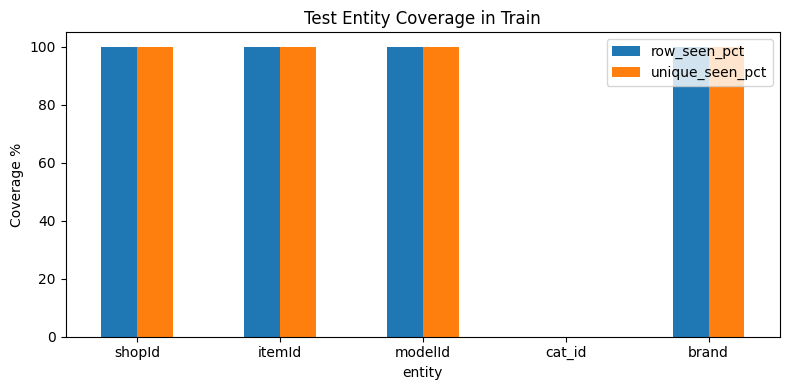

In [12]:
coverage_df.plot(
    x="entity",
    y=["row_seen_pct", "unique_seen_pct"],
    kind="bar",
    figsize=(8, 4),
    title="Test Entity Coverage in Train",
)
plt.ylabel("Coverage %")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 6. Historical Stability By Entity

The entity blend assumes products/models have stable historical prices. This section measures historical count and log-price variability by key.


In [13]:
def entity_stability(df, key):
    tmp = df.dropna(subset=[config.target]).copy()
    tmp["target_log"] = np.log1p(tmp[config.target].clip(lower=0))
    agg = tmp.groupby(key)["target_log"].agg(["count", "median", "std", "min", "max"]).reset_index()
    agg["range_log"] = agg["max"] - agg["min"]
    return agg

stability_summaries = []
for key in ["modelId", "itemId", "shopId", "cat_id", "brand"]:
    agg = entity_stability(train, key)
    stability_summaries.append({
        "key": key,
        "entities": len(agg),
        "median_count": agg["count"].median(),
        "p90_count": agg["count"].quantile(0.90),
        "median_std_log": agg["std"].median(),
        "p90_std_log": agg["std"].quantile(0.90),
        "median_range_log": agg["range_log"].median(),
        "p90_range_log": agg["range_log"].quantile(0.90),
    })

pd.DataFrame(stability_summaries)


,key,entities,median_count,p90_count,median_std_log,p90_std_log,median_range_log,p90_range_log
0,modelId,6286,33.0000,122.0000,0.0000,0.0389,0.0000,0.1054
1,itemId,1594,64.0000,425.4000,0.0000,0.3118,0.0000,0.8189
2,shopId,219,228.0000,"2,908.2000",0.3422,0.9071,0.9763,3.5487
3,cat_id,26,"5,034.0000","34,615.0000",1.0198,1.2382,3.9437,7.4108
4,brand,377,136.0000,"1,106.4000",0.1494,0.6497,0.3644,2.0117


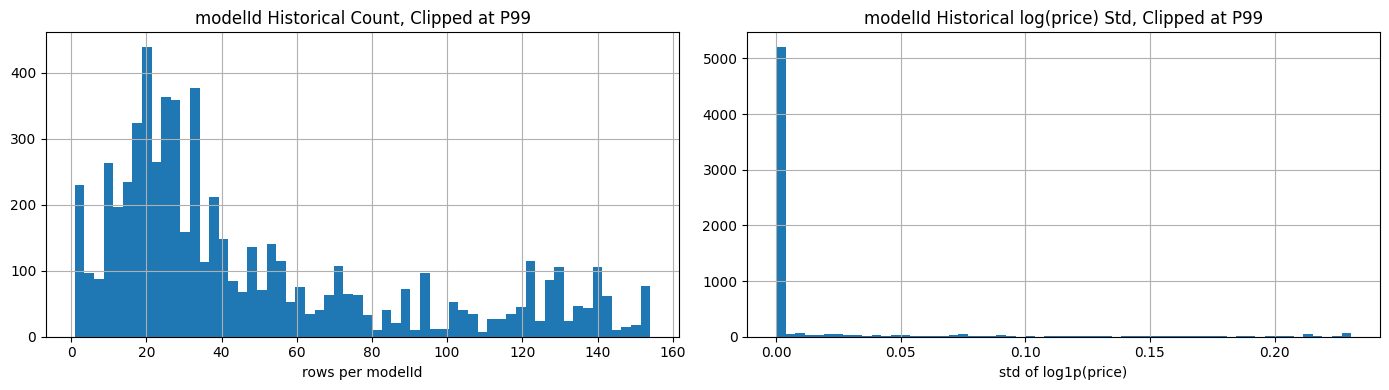

In [14]:
model_stability = entity_stability(train, "modelId")
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

model_stability["count"].clip(upper=model_stability["count"].quantile(0.99)).hist(bins=60, ax=axes[0])
axes[0].set_title("modelId Historical Count, Clipped at P99")
axes[0].set_xlabel("rows per modelId")

model_stability["std"].dropna().clip(upper=model_stability["std"].quantile(0.99)).hist(bins=60, ax=axes[1])
axes[1].set_title("modelId Historical log(price) Std, Clipped at P99")
axes[1].set_xlabel("std of log1p(price)")

plt.tight_layout()
plt.show()


## 7. Recent Price Movement

This checks whether last observed prices might be useful. Large recent movement means simple long-term medians may miss current prices.


In [15]:
train_sorted = train.sort_values(["modelId", config.date_col]).copy()
train_sorted["prev_price"] = train_sorted.groupby("modelId")[config.target].shift(1)
train_sorted["prev_log_price"] = np.log1p(train_sorted["prev_price"].clip(lower=0))
train_sorted["log_price"] = np.log1p(train_sorted[config.target].clip(lower=0))
train_sorted["abs_log_change"] = (train_sorted["log_price"] - train_sorted["prev_log_price"]).abs()

movement = train_sorted.dropna(subset=["abs_log_change"])["abs_log_change"]
movement.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).to_frame("abs_log_change")


,abs_log_change
count,"299,940.0000"
mean,0.0012
std,0.0232
min,0.0000
50%,0.0000
75%,0.0000
90%,0.0000
95%,0.0000
99%,0.0000
max,2.1542


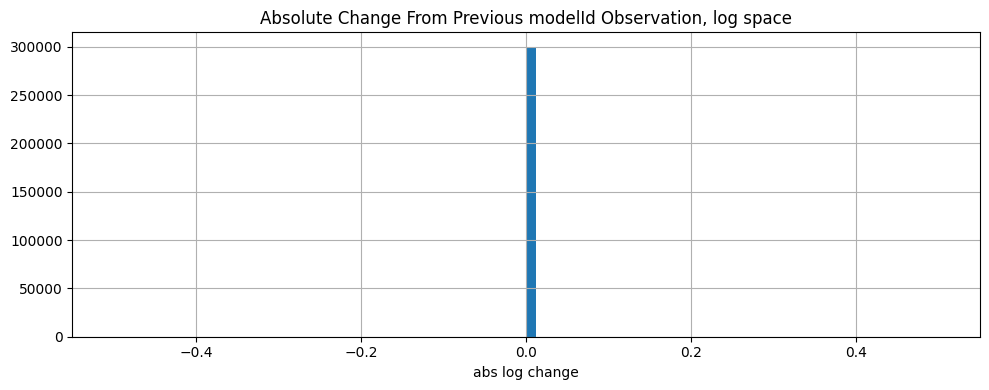

In [16]:
movement.clip(upper=movement.quantile(0.99)).hist(bins=80, figsize=(10, 4))
plt.title("Absolute Change From Previous modelId Observation, log space")
plt.xlabel("abs log change")
plt.tight_layout()
plt.show()


## 8. Test Anchor Rows

Known prices in the test file are anchors. This checks how many anchors exist per day and what parts of the marketplace they cover.


In [17]:
test_anchors = test[test[config.target].notna()].copy()
anchor_summary = test_anchors.groupby("date").agg(
    anchors=(config.target, "size"),
    unique_shopId=("shopId", "nunique"),
    unique_itemId=("itemId", "nunique"),
    unique_modelId=("modelId", "nunique"),
    median_price=(config.target, "median"),
    min_price=(config.target, "min"),
    max_price=(config.target, "max"),
)
anchor_summary


,anchors,unique_shopId,unique_itemId,unique_modelId,median_price,min_price,max_price
date,,,,,,,
2025-03-22,100,37,73,98,"13,850,000.0000","900,000.0000","1,660,000,000.0000"
2025-03-23,100,41,72,94,"16,750,000.0000","500,000.0000","250,000,000.0000"
2025-03-24,100,34,75,98,"11,100,000.0000","300,000.0000","298,000,000.0000"


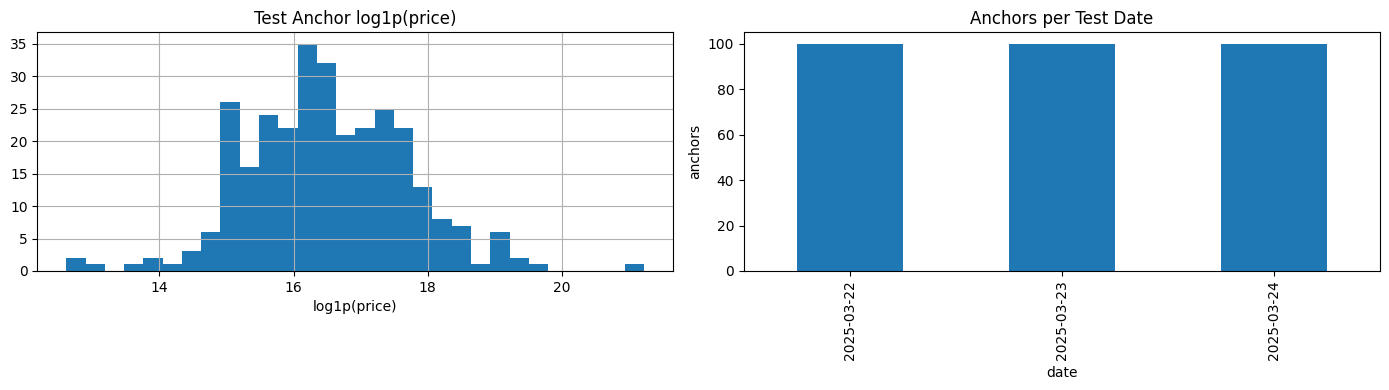

In [18]:
if len(test_anchors):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    np.log1p(test_anchors[config.target]).hist(bins=30, ax=axes[0])
    axes[0].set_title("Test Anchor log1p(price)")
    axes[0].set_xlabel("log1p(price)")

    test_anchors.groupby("date").size().plot(kind="bar", ax=axes[1], title="Anchors per Test Date")
    axes[1].set_ylabel("anchors")
    plt.tight_layout()
    plt.show()
else:
    print("No known test anchor prices found.")


In [19]:
if len(test_anchors):
    pd.DataFrame([coverage(train, test_anchors, col) for col in ["shopId", "itemId", "modelId", "cat_id", "brand"]])
else:
    print("No known test anchor prices found.")


## 9. Validation Error Context

If validation outputs exist, this section summarizes which model variants are performing well and where errors concentrate.


In [21]:
validation_summary_path = config.output_dir / "validation_summary.csv"
validation_segments_path = config.output_dir / "validation_segments.csv"

if validation_summary_path.exists():
    validation_summary = pd.read_csv(validation_summary_path)
    display(validation_summary.sort_values("MAE"))
else:
    print(f"Missing {validation_summary_path}. Run validation first.")

if validation_segments_path.exists():
    validation_segments = pd.read_csv(validation_segments_path)
    for segment in ["date", "price_bucket", "history_count_bucket"]:
        print("", segment)
        display(
            validation_segments
            .query("segment == @segment")
            .sort_values(["segment_value", "MAE"])
            .head(40)
        )
else:
    print(f"Missing {validation_segments_path}. Run validation first.")


,base_model,MAE,RMSE,MAPE
0,entity_blend_no_calibration,"567,332.4319","4,299,505.8017",1.9209
1,anchor_model_selected_entity_blend_calibrated,"574,402.0995","4,224,057.4419",1.9526
2,entity_blend_calibrated,"574,402.0995","4,224,057.4419",1.9526
3,second_stage_residual,"925,830.5311","4,609,500.7831",2.5632
4,global_no_calibration,"933,152.9842","10,554,379.4798",1.5320
5,global_calibrated,"942,028.9786","10,400,296.7867",1.5570


 date


,segment,segment_value,variant,MAE,RMSE,MAPE,n_eval
6,date,2025-03-20,entity_blend_no_calibration,"655,213.1583","5,296,868.2708",1.1744,7893
0,date,2025-03-20,anchor_model_selected_entity_blend_calibrated,"665,184.2635","5,095,095.2151",1.1807,7893
3,date,2025-03-20,entity_blend_calibrated,"665,184.2635","5,095,095.2151",1.1807,7893
12,date,2025-03-20,global_no_calibration,"980,681.0387","12,763,683.4100",1.1380,7893
9,date,2025-03-20,global_calibrated,"997,414.2479","12,354,877.3704",1.1565,7893
15,date,2025-03-20,second_stage_residual,"1,126,436.1895","5,077,718.2203",2.2725,7893
7,date,2025-03-21,entity_blend_no_calibration,"704,075.4780","5,404,202.4923",2.7035,7955
1,date,2025-03-21,anchor_model_selected_entity_blend_calibrated,"712,788.8528","5,390,645.5100",2.7852,7955
4,date,2025-03-21,entity_blend_calibrated,"712,788.8528","5,390,645.5100",2.7852,7955
13,date,2025-03-21,global_no_calibration,"1,153,395.0202","13,131,754.9277",1.9149,7955


 price_bucket


,segment,segment_value,variant,MAE,RMSE,MAPE,n_eval
34,price_bucket,price_q1,global_no_calibration,"53,427.7037","254,807.7993",1.4482,5402
30,price_bucket,price_q1,global_calibrated,"54,025.3803","254,469.2754",1.4548,5402
38,price_bucket,price_q1,second_stage_residual,"98,867.2584","543,454.0911",2.3020,5402
26,price_bucket,price_q1,entity_blend_no_calibration,"105,264.1960","945,408.4508",2.3918,5402
18,price_bucket,price_q1,anchor_model_selected_entity_blend_calibrated,"106,737.7129","945,281.6067",2.4120,5402
22,price_bucket,price_q1,entity_blend_calibrated,"106,737.7129","945,281.6067",2.4120,5402
35,price_bucket,price_q2,global_no_calibration,"173,904.9416","1,207,208.9241",1.5821,5032
31,price_bucket,price_q2,global_calibrated,"181,210.0497","1,207,946.3202",1.6482,5032
27,price_bucket,price_q2,entity_blend_no_calibration,"274,035.9456","1,917,543.9673",2.7858,5032
19,price_bucket,price_q2,anchor_model_selected_entity_blend_calibrated,"284,938.4243","1,914,463.4731",2.8850,5032


 history_count_bucket


,segment,segment_value,variant,MAE,RMSE,MAPE,n_eval
62,history_count_bucket,1-5,second_stage_residual,"2,862,024.9830","7,773,482.5254",2.4072,203
42,history_count_bucket,1-5,anchor_model_selected_entity_blend_calibrated,"3,547,935.2254","9,174,024.6139",2.5783,203
46,history_count_bucket,1-5,entity_blend_calibrated,"3,547,935.2254","9,174,024.6139",2.5783,203
50,history_count_bucket,1-5,entity_blend_no_calibration,"3,614,109.4170","9,467,247.6835",2.5651,203
54,history_count_bucket,1-5,global_calibrated,"3,919,649.6299","10,045,468.1393",2.8344,203
58,history_count_bucket,1-5,global_no_calibration,"3,981,156.7032","10,388,890.3922",2.8019,203
51,history_count_bucket,100+,entity_blend_no_calibration,"577,183.5974","3,225,828.8916",3.2148,8769
43,history_count_bucket,100+,anchor_model_selected_entity_blend_calibrated,"590,386.2206","3,204,781.9408",3.2972,8769
47,history_count_bucket,100+,entity_blend_calibrated,"590,386.2206","3,204,781.9408",3.2972,8769
59,history_count_bucket,100+,global_no_calibration,"750,684.2788","7,194,546.0439",1.9065,8769


## 10. Anchor Set vs Previous History

This section treats known prices in the test file as the anchor set and compares each anchor against historical rows from before the anchor timestamp.

The goal is to answer:

- Are anchor prices mostly equal to the last known same-`modelId` price?
- Are changes concentrated by day, shop, category, brand, or price bucket?
- Which history key is most useful for anchor correction: `modelId`, `itemId`, or `shopId`?
- Does the anchor set suggest global calibration, segment calibration, or no calibration?

For each anchor row, we compute prior same-key statistics using training rows only:

- last historical price before the anchor timestamp
- recent median over last 3 and last 7 observations
- all-history median
- count of prior observations
- log residual: `log(anchor_price) - log(history_reference_price)`


In [22]:
anchors = test[test[config.target].notna()].copy().reset_index(drop=True)
anchors["anchor_row_id"] = np.arange(len(anchors))
anchors["anchor_log_price"] = np.log1p(anchors[config.target].clip(lower=0))

print("Anchor rows:", len(anchors))
display(
    anchors.groupby("date").agg(
        anchors=(config.target, "size"),
        unique_shopId=("shopId", "nunique"),
        unique_itemId=("itemId", "nunique"),
        unique_modelId=("modelId", "nunique"),
        median_price=(config.target, "median"),
        min_price=(config.target, "min"),
        max_price=(config.target, "max"),
    )
)


Anchor rows: 300


,anchors,unique_shopId,unique_itemId,unique_modelId,median_price,min_price,max_price
date,,,,,,,
2025-03-22,100,37,73,98,"13,850,000.0000","900,000.0000","1,660,000,000.0000"
2025-03-23,100,41,72,94,"16,750,000.0000","500,000.0000","250,000,000.0000"
2025-03-24,100,34,75,98,"11,100,000.0000","300,000.0000","298,000,000.0000"


In [23]:
def prior_stats_for_key(train_df, anchor_df, key, windows=(3, 7)):
    history_cols = [key, config.date_col, config.target]
    hist = train_df[history_cols].dropna(subset=[config.target]).copy()
    hist = hist.rename(columns={config.date_col: "hist_time", config.target: "hist_price"})
    hist[key] = hist[key].astype(str)
    hist["hist_log_price"] = np.log1p(hist["hist_price"].clip(lower=0))
    hist = hist.sort_values([key, "hist_time"])

    anchor_side = anchor_df[["anchor_row_id", key, config.date_col, config.target, "date"]].copy()
    anchor_side = anchor_side.rename(columns={config.date_col: "anchor_time", config.target: "anchor_price"})
    anchor_side[key] = anchor_side[key].astype(str)

    merged = anchor_side.merge(hist, on=key, how="left")
    merged = merged[merged["hist_time"] < merged["anchor_time"]].copy()
    merged = merged.sort_values(["anchor_row_id", "hist_time"])

    if merged.empty:
        out = anchor_df[["anchor_row_id"]].copy()
        out[f"{key}_prior_count"] = 0
        out[f"{key}_last_price"] = np.nan
        out[f"{key}_all_median_price"] = np.nan
        for w in windows:
            out[f"{key}_last_{w}_median_price"] = np.nan
        return out

    rows = []
    for anchor_id, group in merged.groupby("anchor_row_id"):
        row = {"anchor_row_id": anchor_id, f"{key}_prior_count": len(group)}
        row[f"{key}_last_price"] = group["hist_price"].iloc[-1]
        row[f"{key}_all_median_price"] = group["hist_price"].median()
        for w in windows:
            row[f"{key}_last_{w}_median_price"] = group["hist_price"].tail(w).median()
        rows.append(row)

    return pd.DataFrame(rows)

anchor_history = anchors.copy()
for key in ["modelId", "itemId", "shopId"]:
    stats = prior_stats_for_key(train, anchors, key)
    anchor_history = anchor_history.merge(stats, on="anchor_row_id", how="left")
    anchor_history[f"{key}_prior_count"] = anchor_history[f"{key}_prior_count"].fillna(0).astype(int)

for key in ["modelId", "itemId", "shopId"]:
    for ref in ["last_price", "last_3_median_price", "last_7_median_price", "all_median_price"]:
        col = f"{key}_{ref}"
        anchor_history[f"{col}_log_delta"] = (
            anchor_history["anchor_log_price"] - np.log1p(anchor_history[col].clip(lower=0))
        )
        anchor_history[f"{col}_pct_delta"] = (
            (anchor_history[config.target] - anchor_history[col]) / anchor_history[col]
        ) * 100

anchor_history.head()


,capturedAt,shopId,itemId,modelId,price,priceBeforeDiscount,promotionId,cat_id,stock,normal_stock,raw_discount,show_discount,brand,is_free_shipping,is_pre_order,item_price_min,item_price_max,review_rating,total_rating_count,cmt_count,shop_rating,shop_response_rate,shop_follower_count,is_official_shop,is_verified,is_preferred_plus_seller,date,anchor_row_id,anchor_log_price,modelId_prior_count,modelId_last_price,modelId_all_median_price,modelId_last_3_median_price,modelId_last_7_median_price,itemId_prior_count,itemId_last_price,itemId_all_median_price,itemId_last_3_median_price,itemId_last_7_median_price,shopId_prior_count,shopId_last_price,shopId_all_median_price,shopId_last_3_median_price,shopId_last_7_median_price,modelId_last_price_log_delta,modelId_last_price_pct_delta,modelId_last_3_median_price_log_delta,modelId_last_3_median_price_pct_delta,modelId_last_7_median_price_log_delta,modelId_last_7_median_price_pct_delta,modelId_all_median_price_log_delta,modelId_all_median_price_pct_delta,itemId_last_price_log_delta,itemId_last_price_pct_delta,itemId_last_3_median_price_log_delta,itemId_last_3_median_price_pct_delta,itemId_last_7_median_price_log_delta,itemId_last_7_median_price_pct_delta,itemId_all_median_price_log_delta,itemId_all_median_price_pct_delta,shopId_last_price_log_delta,shopId_last_price_pct_delta,shopId_last_3_median_price_log_delta,shopId_last_3_median_price_pct_delta,shopId_last_7_median_price_log_delta,shopId_last_7_median_price_pct_delta,shopId_all_median_price_log_delta,shopId_all_median_price_pct_delta
0,2025-03-22 04:27:05.388,1009757562,22983470729,241402913254,"42,500,000.0000",0.0000,0.0,100001.0,NaN,NaN,0.0000,0.0000,durex 杜蕾斯,0,0,"9,900,000.0000","49,500,000.0000",5.0000,21.0000,20.0000,4.9734,96.0000,"3,927.0000",0,0,0,2025-03-22,0,17.5650,121,42500000,"42,500,000.0000","42,500,000.0000","42,500,000.0000",2662,25300000,"25,050,000.0000","25,300,000.0000","25,300,000.0000",20024,28400000,"14,900,000.0000","29,100,000.0000","28,400,000.0000",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.5187,67.9842,0.5187,67.9842,0.5187,67.9842,0.5286,69.6607,0.4031,49.6479,0.3788,46.0481,0.4031,49.6479,1.0481,185.2349
1,2025-03-22 04:53:32.412,1010118847,22760898836,255025844230,"28,500,000.0000",0.0000,0.0,100636.0,NaN,NaN,0.0000,0.0000,missing,0,0,"28,500,000.0000","29,500,000.0000",4.9451,255.0000,243.0000,4.9365,83.0000,"1,167.0000",0,1,0,2025-03-22,1,17.1654,101,28500000,"28,500,000.0000","28,500,000.0000","28,500,000.0000",1212,29500000,"29,500,000.0000","29,500,000.0000","29,500,000.0000",2136,2500000,"28,500,000.0000","2,500,000.0000","2,700,000.0000",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0345,-3.3898,-0.0345,-3.3898,-0.0345,-3.3898,-0.0345,-3.3898,2.4336,"1,040.0000",2.4336,"1,040.0000",2.3567,955.5556,0.0000,0.0000
2,2025-03-22 04:53:32.839,1007168904,25014396500,214922892911,"11,500,000.0000","18,900,000.0000",607756672303104.0,100636.0,NaN,NaN,39.0000,39.0000,3M,0,0,"11,500,000.0000","11,500,000.0000",4.9503,161.0000,148.0000,4.9656,70.0000,611.0000,0,0,0,2025-03-22,2,16.2579,82,11500000,"11,500,000.0000","11,500,000.0000","11,500,000.0000",82,11500000,"11,500,000.0000","11,500,000.0000","11,500,000.0000",21392,5500000,"10,900,000.0000","5,500,000.0000","5,500,000.0000",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.7376,109.0909,0.7376,109.0909,0.7376,109.0909,0.0536,5.5046
3,2025-03-22 04:53:32.839,1007168904,25014396500,214922892911,"11,500,000.0000","18,900,000.0000",607756672303104.0,100636.0,NaN,NaN,39.0000,39.0000,3M,0,0,"11,500,000.0000","11,500,000.0000",4.9503,161.0000,148.0000,4.9656,70.0000,611.0000,0,0,0,2025-03-22,3,16.2579,82,11500000,"11,500,000.0000","11,500,000.0000","11,500,000.0000",82,11500000,"11,500,000.0000","11,500,000.0000","11,500,000.0000",21392,5500000,"10,900,000.0000","5,500,000.0000","5,500,000.0000",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000

### Anchor Historical Coverage

If most anchors have prior same-`modelId` history, then model-level historical priors should be very strong. If not, fallback to `itemId` or `shopId` matters more.


In [24]:
coverage_rows = []
for key in ["modelId", "itemId", "shopId"]:
    count_col = f"{key}_prior_count"
    coverage_rows.append({
        "key": key,
        "anchors_with_history": (anchor_history[count_col] > 0).sum(),
        "anchors_without_history": (anchor_history[count_col] == 0).sum(),
        "coverage_pct": (anchor_history[count_col] > 0).mean() * 100,
        "median_prior_count": anchor_history[count_col].median(),
        "p10_prior_count": anchor_history[count_col].quantile(0.10),
        "p90_prior_count": anchor_history[count_col].quantile(0.90),
    })

pd.DataFrame(coverage_rows)


,key,anchors_with_history,anchors_without_history,coverage_pct,median_prior_count,p10_prior_count,p90_prior_count
0,modelId,300,0,100.0000,89.0000,21.0000,141.0000
1,itemId,300,0,100.0000,612.0000,63.6000,"4,356.0000"
2,shopId,300,0,100.0000,"5,243.0000",677.7000,"52,925.0000"


### Which Prior Best Matches Anchors?

This compares anchor price against several same-key historical references. Lower absolute log delta means the historical reference is closer to the anchor.


In [25]:
prior_error_rows = []
for key in ["modelId", "itemId", "shopId"]:
    for ref in ["last_price", "last_3_median_price", "last_7_median_price", "all_median_price"]:
        delta_col = f"{key}_{ref}_log_delta"
        valid = anchor_history[delta_col].replace([np.inf, -np.inf], np.nan).dropna()
        prior_error_rows.append({
            "reference": f"{key}_{ref}",
            "n_valid": len(valid),
            "median_abs_log_delta": valid.abs().median(),
            "mean_abs_log_delta": valid.abs().mean(),
            "p90_abs_log_delta": valid.abs().quantile(0.90),
            "median_signed_log_delta": valid.median(),
            "pct_exact_match": (valid.abs() < 1e-9).mean() * 100 if len(valid) else np.nan,
            "pct_within_1pct_log": (valid.abs() <= 0.01).mean() * 100 if len(valid) else np.nan,
            "pct_within_5pct_log": (valid.abs() <= 0.05).mean() * 100 if len(valid) else np.nan,
        })

prior_error_summary = pd.DataFrame(prior_error_rows).sort_values("median_abs_log_delta")
prior_error_summary


,reference,n_valid,median_abs_log_delta,mean_abs_log_delta,p90_abs_log_delta,median_signed_log_delta,pct_exact_match,pct_within_1pct_log,pct_within_5pct_log
0,modelId_last_price,300,0.0000,0.0001,0.0000,0.0000,99.6667,99.6667,100.0000
1,modelId_last_3_median_price,300,0.0000,0.0004,0.0000,0.0000,99.3333,99.3333,99.6667
2,modelId_last_7_median_price,300,0.0000,0.0004,0.0000,0.0000,99.3333,99.3333,99.6667
3,modelId_all_median_price,300,0.0000,0.0135,0.0000,0.0000,94.6667,95.3333,97.0000
4,itemId_last_price,300,0.0000,0.1474,0.5366,0.0000,64.0000,64.0000,66.6667
5,itemId_last_3_median_price,300,0.0000,0.1341,0.4138,0.0000,64.0000,64.3333,67.3333
6,itemId_last_7_median_price,300,0.0000,0.1269,0.4172,0.0000,64.0000,64.0000,67.3333
7,itemId_all_median_price,300,0.0000,0.1309,0.4142,0.0000,56.0000,57.0000,62.6667
11,shopId_all_median_price,300,0.3329,0.5864,1.6864,0.0000,20.6667,20.6667,24.0000
8,shopId_last_price,300,0.3637,0.6473,1.7719,0.0000,20.0000,20.3333,24.0000


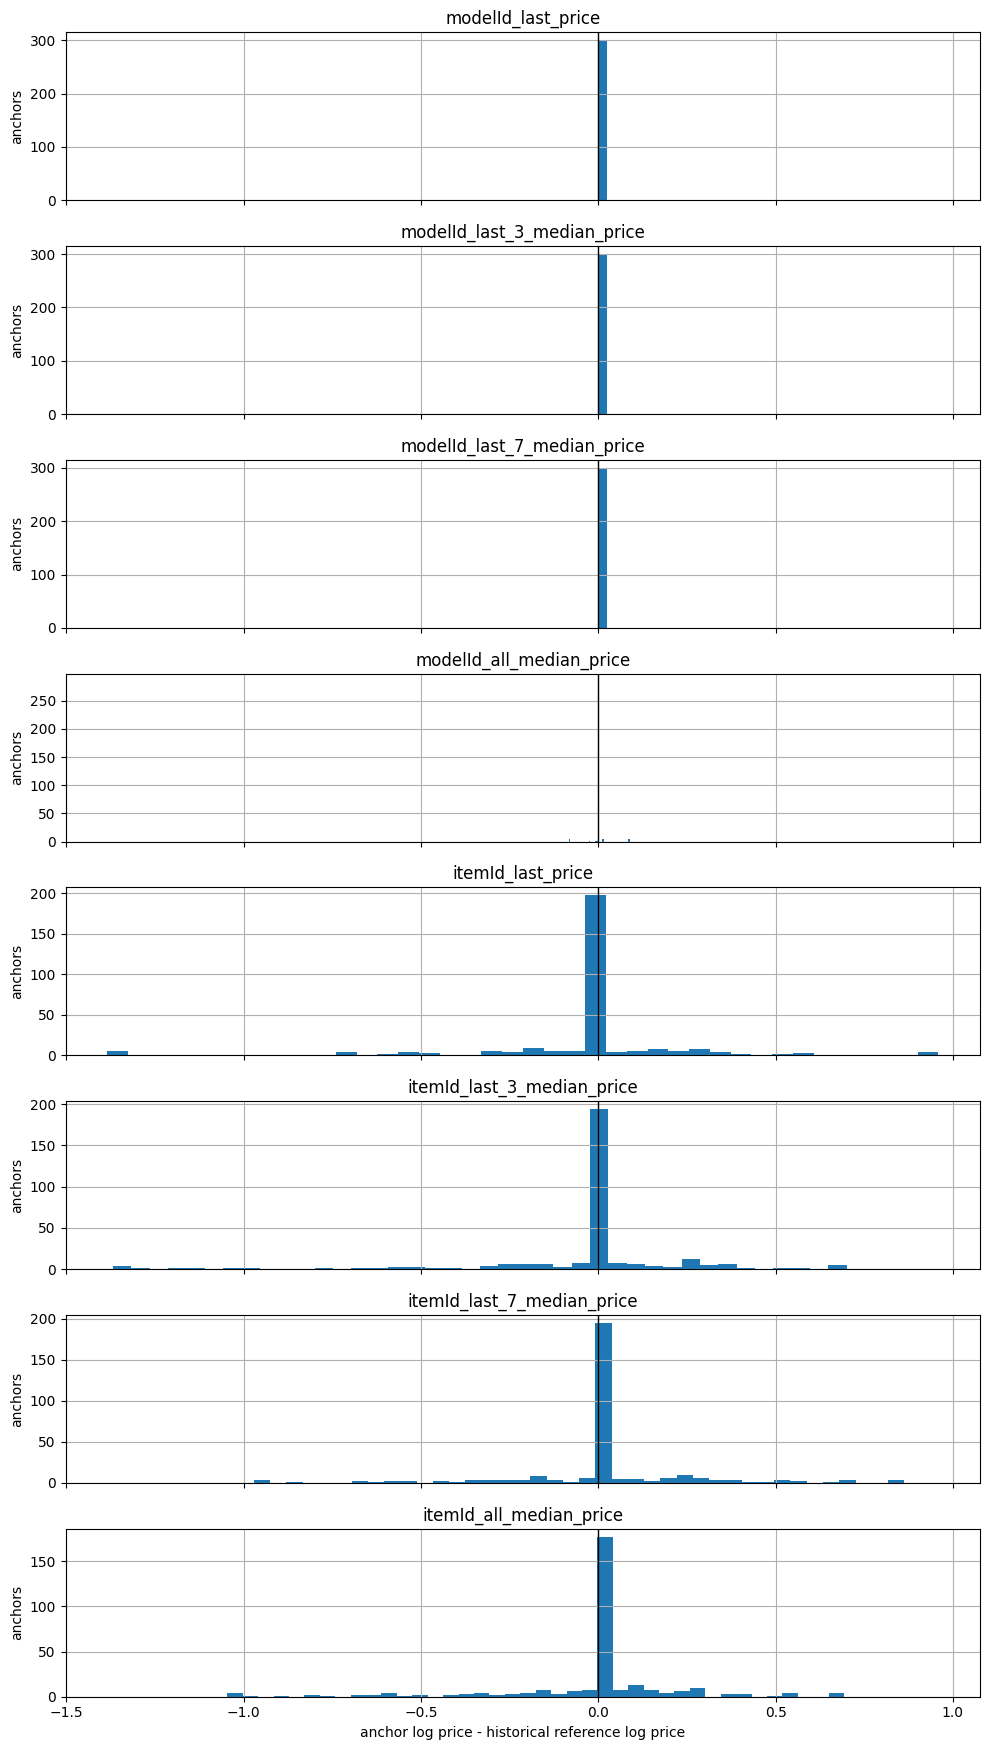

In [26]:
best_refs = prior_error_summary.head(8)["reference"].tolist()
fig, axes = plt.subplots(len(best_refs), 1, figsize=(10, max(3, 2.2 * len(best_refs))), sharex=True)
if len(best_refs) == 1:
    axes = [axes]

for ax, ref_name in zip(axes, best_refs):
    delta_col = f"{ref_name}_log_delta"
    vals = anchor_history[delta_col].replace([np.inf, -np.inf], np.nan).dropna()
    vals.clip(lower=vals.quantile(0.01), upper=vals.quantile(0.99)).hist(bins=40, ax=ax)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(ref_name)
    ax.set_ylabel("anchors")

axes[-1].set_xlabel("anchor log price - historical reference log price")
plt.tight_layout()
plt.show()


### Anchor Shifts By Date And Segment

This shows whether anchor shifts are global or concentrated by day/shop/category/brand/price bucket. Use the best historical reference from the table above, usually same-`modelId` last price or recent median.


In [27]:
REFERENCE_DELTA_COL = "modelId_last_price_log_delta"
REFERENCE_PCT_COL = "modelId_last_price_pct_delta"

anchor_history["anchor_price_bucket"] = pd.qcut(
    anchor_history[config.target],
    q=4,
    labels=["anchor_q1", "anchor_q2", "anchor_q3", "anchor_q4"],
    duplicates="drop",
).astype(str)

def segment_anchor_shift(df, group_col, delta_col=REFERENCE_DELTA_COL):
    valid = df.replace([np.inf, -np.inf], np.nan).dropna(subset=[delta_col])
    return (
        valid.groupby(group_col)
        .agg(
            anchors=(delta_col, "size"),
            median_log_delta=(delta_col, "median"),
            mean_abs_log_delta=(delta_col, lambda x: x.abs().mean()),
            p90_abs_log_delta=(delta_col, lambda x: x.abs().quantile(0.90)),
            exact_match_pct=(delta_col, lambda x: (x.abs() < 1e-9).mean() * 100),
            within_5pct_log_pct=(delta_col, lambda x: (x.abs() <= 0.05).mean() * 100),
        )
        .reset_index()
        .sort_values(["mean_abs_log_delta", "anchors"], ascending=[False, False])
    )

for group_col in ["date", "anchor_price_bucket", "shopId", "brand", "cat_id"]:
    print("", group_col)
    display(segment_anchor_shift(anchor_history, group_col).head(20))


 date


,date,anchors,median_log_delta,mean_abs_log_delta,p90_abs_log_delta,exact_match_pct,within_5pct_log_pct
1,2025-03-23,100,0.0000,0.0003,0.0000,99.0000,100.0000
0,2025-03-22,100,0.0000,0.0000,0.0000,100.0000,100.0000
2,2025-03-24,100,0.0000,0.0000,0.0000,100.0000,100.0000


 anchor_price_bucket


,anchor_price_bucket,anchors,median_log_delta,mean_abs_log_delta,p90_abs_log_delta,exact_match_pct,within_5pct_log_pct
1,anchor_q2,70,0.0000,0.0004,0.0000,98.5714,100.0000
0,anchor_q1,80,0.0000,0.0000,0.0000,100.0000,100.0000
2,anchor_q3,75,0.0000,0.0000,0.0000,100.0000,100.0000
3,anchor_q4,75,0.0000,0.0000,0.0000,100.0000,100.0000


 shopId


,shopId,anchors,median_log_delta,mean_abs_log_delta,p90_abs_log_delta,exact_match_pct,within_5pct_log_pct
61,1009293775,7,0.0000,0.0036,0.0101,85.7143,100.0000
24,1005099271,61,0.0000,0.0000,0.0000,100.0000,100.0000
45,1007168904,25,0.0000,0.0000,0.0000,100.0000,100.0000
64,1009757562,23,0.0000,0.0000,0.0000,100.0000,100.0000
31,1005619933,16,0.0000,0.0000,0.0000,100.0000,100.0000
65,1009833148,12,0.0000,0.0000,0.0000,100.0000,100.0000
18,100423447,9,0.0000,0.0000,0.0000,100.0000,100.0000
59,1008737,9,0.0000,0.0000,0.0000,100.0000,100.0000
63,1009676594,9,0.0000,0.0000,0.0000,100.0000,100.0000
6,10032825,8,0.0000,0.0000,0.0000,100.0000,100.0000


 brand


,brand,anchors,median_log_delta,mean_abs_log_delta,p90_abs_log_delta,exact_match_pct,within_5pct_log_pct
7,Biore 蜜妮,6,0.0000,0.0042,0.0127,83.3333,100.0000
62,missing,134,0.0000,0.0000,0.0000,100.0000,100.0000
0,3M,21,0.0000,0.0000,0.0000,100.0000,100.0000
10,Conifer 綠的,6,0.0000,0.0000,0.0000,100.0000,100.0000
22,Le Serail,6,0.0000,0.0000,0.0000,100.0000,100.0000
39,RAINBOW 虹牌油漆,6,0.0000,0.0000,0.0000,100.0000,100.0000
27,Mr Muscle 威猛先生,5,0.0000,0.0000,0.0000,100.0000,100.0000
38,Panasonic 國際牌,5,0.0000,0.0000,0.0000,100.0000,100.0000
1,ACE,4,0.0000,0.0000,0.0000,100.0000,100.0000
4,Ariel,4,0.0000,0.0000,0.0000,100.0000,100.0000


 cat_id


,cat_id,anchors,median_log_delta,mean_abs_log_delta,p90_abs_log_delta,exact_match_pct,within_5pct_log_pct
12,100630.0,37,0.0000,0.0007,0.0000,97.2973,100.0000
17,100636.0,72,0.0000,0.0000,0.0000,100.0000,100.0000
6,100015.0,38,0.0000,0.0000,0.0000,100.0000,100.0000
0,100001.0,36,0.0000,0.0000,0.0000,100.0000,100.0000
19,100638.0,17,0.0000,0.0000,0.0000,100.0000,100.0000
15,100633.0,16,0.0000,0.0000,0.0000,100.0000,100.0000
4,100012.0,12,0.0000,0.0000,0.0000,100.0000,100.0000
14,100632.0,11,0.0000,0.0000,0.0000,100.0000,100.0000
11,100629.0,10,0.0000,0.0000,0.0000,100.0000,100.0000
2,100010.0,9,0.0000,0.0000,0.0000,100.0000,100.0000


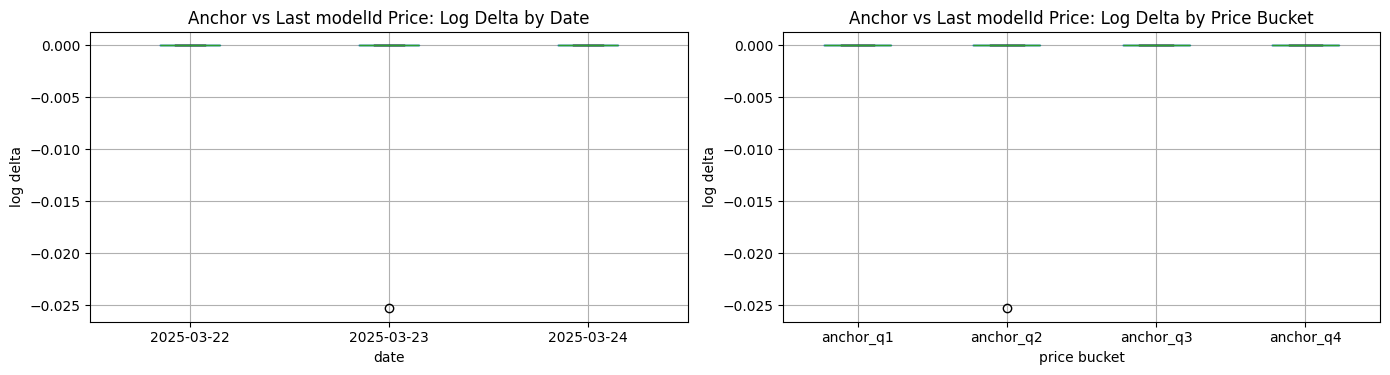

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

anchor_history.boxplot(column=REFERENCE_DELTA_COL, by="date", ax=axes[0])
axes[0].set_title("Anchor vs Last modelId Price: Log Delta by Date")
axes[0].set_xlabel("date")
axes[0].set_ylabel("log delta")

anchor_history.boxplot(column=REFERENCE_DELTA_COL, by="anchor_price_bucket", ax=axes[1])
axes[1].set_title("Anchor vs Last modelId Price: Log Delta by Price Bucket")
axes[1].set_xlabel("price bucket")
axes[1].set_ylabel("log delta")

plt.suptitle("")
plt.tight_layout()
plt.show()


### Implications For Anchor Utilization

Use this table to decide how anchors should affect predictions:

- If `median_signed_log_delta` is close to zero and most anchors exactly match recent history, global calibration is probably unnecessary.
- If shifts are consistent by date, use global day calibration.
- If shifts are concentrated by `shopId`, `cat_id`, or `brand`, segment calibration may help.
- If sparse-history anchors have larger shifts, second-stage or neighbor-based correction may be useful only for sparse-history rows.
- If anchor shifts are noisy, use anchors for diagnostics/model selection rather than applying corrections broadly.


## EDA Takeaways To Fill In

Use this section after running the notebook:

- Is the train/test boundary timestamp-based or date-based?
- Which test columns are mostly missing?
- Are test entities mostly seen in train?
- Which entity level is most stable: `modelId`, `itemId`, `shopId`, category, or brand?
- Are recent price movements large enough to justify rolling/last-price features?
- Do anchors cover enough categories/shops to support calibration?
- Which validation segments are hardest: sparse history, high price, low price, or specific dates?
